In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

FILE_PATH = "決定版.csv"

# 文字コードを順番に試して読み込む
encodings = ["utf-8-sig", "utf-8", "cp932", "shift_jis"]

for enc in encodings:
    try:
        df = pd.read_csv(FILE_PATH, encoding=enc)
        print("読み込み成功:", enc)
        break
    except UnicodeDecodeError:
        print("失敗:", enc)

print("データ行数:", len(df))
print("列数:", len(df.columns))
print("列名一覧:")
print(df.columns.tolist())

df.head()

読み込み成功: utf-8-sig
データ行数: 7338
列数: 39
列名一覧:
['日付', '球団', '対戦相手', '打者名', '打順', 'イニング', '表裏', 'イニング内打席番号', '自チーム打席前得点', '相手チーム打席前得点', '打席前点差', '打席前アウト数', '打席前走者状況コード', '打席前一塁走者', '打席前二塁走者', '打席前三塁走者', '打席前状況コード', '打席結果', 'この打席得点数', '打点', '自チーム打席後得点', '相手チーム打席後得点', '打席後点差', '打席後アウト数', '打席後走者状況コード', '打席後一塁走者', '打席後二塁走者', '打席後三塁走者', '打席後状況コード', '得点圏フラグ', '打者走者進塁先', '打席前RE', '打席後RE', 'RE24', '打席前WE', '打席後WE', 'WPA', 'WEサンプル数_前', 'WEサンプル数_後']


,日付,球団,対戦相手,打者名,打順,イニング,表裏,イニング内打席番号,自チーム打席前得点,相手チーム打席前得点,...,得点圏フラグ,打者走者進塁先,打席前RE,打席後RE,RE24,打席前WE,打席後WE,WPA,WEサンプル数_前,WEサンプル数_後
0,2025-03-28,巨人,ヤクルト,岡本 和真,4,1,裏,4,0,0,...,1,0,1.016,0.431,-0.585,0.714286,0.521739,-0.192547,14,23
1,2025-03-28,ヤクルト,巨人,サンタナ,4,2,表,1,0,0,...,0,0,0.365,0.189,-0.176,0.463250,0.432540,-0.030710,517,378
2,2025-03-28,巨人,ヤクルト,岡本 和真,4,3,裏,2,0,0,...,0,0,0.189,0.074,-0.115,0.526906,0.505525,-0.021381,223,181
3,2025-03-28,ヤクルト,巨人,サンタナ,4,5,表,1,0,0,...,0,1,0.365,0.675,0.310,0.479167,0.632353,0.153186,192,34
4,2025-03-28,ヤクルト,巨人,サンタナ,4,6,表,1,4,0,...,0,4,0.365,0.365,1.000,0.871795,0.875000,0.003205,39,16


In [90]:
keywords = ["打者", "球団", "打点", "RE24", "WPA", "本塁打", "HR"]

for keyword in keywords:
    print(f"\n【{keyword}を含む列】")
    print([col for col in df.columns if keyword in str(col)])


【打者を含む列】
['打者名', '打者走者進塁先']

【球団を含む列】
['球団']

【打点を含む列】
['打点']

【RE24を含む列】
['RE24']

【WPAを含む列】
['WPA']

【本塁打を含む列】
[]

【HRを含む列】
[]


In [91]:
batter_col = "打者名"
team_col = "球団"
rbi_col = "打点"
re24_col = "RE24"
wpa_col = "WPA"

# HR列があるか自動で探す
hr_candidates = [
    col for col in df.columns
    if "本塁打" in str(col) or str(col).upper() == "HR"
]

hr_col = hr_candidates[0] if len(hr_candidates) > 0 else None

print("打者列:", batter_col)
print("球団列:", team_col)
print("打点列:", rbi_col)
print("RE24列:", re24_col)
print("WPA列:", wpa_col)
print("HR列:", hr_col)

打者列: 打者名
球団列: 球団
打点列: 打点
RE24列: RE24
WPA列: WPA
HR列: None


In [92]:
numeric_cols = [rbi_col, re24_col, wpa_col]

if hr_col is not None:
    numeric_cols.append(hr_col)

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("数値列の欠損数")
print(df[numeric_cols].isna().sum())

数値列の欠損数
打点      0
RE24    0
WPA     0
dtype: int64


In [93]:
summary = (
    df.groupby([team_col, batter_col])
    .agg(
        PA=(batter_col, "count"),
        打点合計=(rbi_col, "sum"),
        RE24合計=(re24_col, "sum"),
        WPA合計=(wpa_col, "sum")
    )
    .reset_index()
)

# HR列がある場合だけ追加
if hr_col is not None:
    hr_summary = (
        df.groupby([team_col, batter_col])[hr_col]
        .sum()
        .reset_index()
        .rename(columns={hr_col: "HR合計"})
    )
    summary = summary.merge(hr_summary, on=[team_col, batter_col], how="left")

summary = summary.sort_values("PA", ascending=False)

summary.head(20)

,球団,打者名,PA,打点合計,RE24合計,WPA合計
156,阪神,佐藤 輝明,544,91,47.723,3.238965
149,西武,ネビン,491,54,21.654,0.468037
84,中日,細川 成也,313,43,19.930,3.654191
22,オリックス,杉本 裕太郎,308,29,-8.236,0.965217
34,ソフトバンク,山川 穂高,289,35,0.287,0.849737
93,巨人,岡本 和真,280,49,28.686,4.366410
44,ヤクルト,オスナ,273,30,3.214,0.736590
110,広島,末包 昇大,267,40,10.932,-0.075041
10,DeNA,牧 秀悟,243,27,8.321,5.049012
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346


In [94]:
summary_100 = summary[summary["PA"] >= 100].copy()

print("PA100以上の選手数:", len(summary_100))

summary_100.sort_values("PA", ascending=False).head(20)

PA100以上の選手数: 25


,球団,打者名,PA,打点合計,RE24合計,WPA合計
156,阪神,佐藤 輝明,544,91,47.723,3.238965
149,西武,ネビン,491,54,21.654,0.468037
84,中日,細川 成也,313,43,19.930,3.654191
22,オリックス,杉本 裕太郎,308,29,-8.236,0.965217
34,ソフトバンク,山川 穂高,289,35,0.287,0.849737
93,巨人,岡本 和真,280,49,28.686,4.366410
44,ヤクルト,オスナ,273,30,3.214,0.736590
110,広島,末包 昇大,267,40,10.932,-0.075041
10,DeNA,牧 秀悟,243,27,8.321,5.049012
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346


In [95]:
rank_df = summary_100.copy()

rank_df["打点順位"] = rank_df["打点合計"].rank(ascending=False, method="min").astype(int)
rank_df["RE24順位"] = rank_df["RE24合計"].rank(ascending=False, method="min").astype(int)
rank_df["WPA順位"] = rank_df["WPA合計"].rank(ascending=False, method="min").astype(int)

# プラスなら「打点順位よりWPA順位が良い」
rank_df["WPA評価上昇"] = rank_df["打点順位"] - rank_df["WPA順位"]

rank_df[
    [team_col, batter_col, "PA", "打点合計", "RE24合計", "WPA合計", 
     "打点順位", "RE24順位", "WPA順位", "WPA評価上昇"]
].sort_values("打点順位").head(20)

,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点順位,RE24順位,WPA順位,WPA評価上昇
156,阪神,佐藤 輝明,544,91,47.723,3.238965,1,1,6,-5
149,西武,ネビン,491,54,21.654,0.468037,2,5,18,-16
93,巨人,岡本 和真,280,49,28.686,4.366410,3,3,3,0
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346,4,2,4,0
84,中日,細川 成也,313,43,19.930,3.654191,5,6,5,0
110,広島,末包 昇大,267,40,10.932,-0.075041,6,7,20,-14
113,日本ハム,レイエス,157,40,25.210,4.825634,6,4,2,4
34,ソフトバンク,山川 穂高,289,35,0.287,0.849737,8,18,14,-6
44,ヤクルト,オスナ,273,30,3.214,0.736590,9,16,16,-7
22,オリックス,杉本 裕太郎,308,29,-8.236,0.965217,10,25,13,-3


In [96]:
# PAあたりの指標を追加
rank_df = summary_100.copy()

rank_df["打点/PA"] = rank_df["打点合計"] / rank_df["PA"]
rank_df["RE24/PA"] = rank_df["RE24合計"] / rank_df["PA"]
rank_df["WPA/PA"] = rank_df["WPA合計"] / rank_df["PA"]

# 合計値の順位
rank_df["打点順位"] = rank_df["打点合計"].rank(ascending=False, method="min").astype(int)
rank_df["RE24順位"] = rank_df["RE24合計"].rank(ascending=False, method="min").astype(int)
rank_df["WPA順位"] = rank_df["WPA合計"].rank(ascending=False, method="min").astype(int)

# PAあたり順位
rank_df["打点/PA順位"] = rank_df["打点/PA"].rank(ascending=False, method="min").astype(int)
rank_df["RE24/PA順位"] = rank_df["RE24/PA"].rank(ascending=False, method="min").astype(int)
rank_df["WPA/PA順位"] = rank_df["WPA/PA"].rank(ascending=False, method="min").astype(int)

# 打点順位とWPA順位の差
rank_df["WPA評価上昇"] = rank_df["打点順位"] - rank_df["WPA順位"]

rank_df[
    [team_col, batter_col, "PA",
     "打点合計", "RE24合計", "WPA合計",
     "打点/PA", "RE24/PA", "WPA/PA",
     "打点順位", "RE24順位", "WPA順位",
     "RE24/PA順位", "WPA/PA順位"]
].sort_values("RE24順位").head(20)

,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,打点順位,RE24順位,WPA順位,RE24/PA順位,WPA/PA順位
156,阪神,佐藤 輝明,544,91,47.723,3.238965,0.167279,0.087726,0.005954,1,1,6,4,10
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346,0.211712,0.140410,0.018110,4,2,4,2,3
93,巨人,岡本 和真,280,49,28.686,4.366410,0.175000,0.102450,0.015594,3,3,3,3,4
113,日本ハム,レイエス,157,40,25.210,4.825634,0.254777,0.160573,0.030737,6,4,2,1,1
149,西武,ネビン,491,54,21.654,0.468037,0.109980,0.044102,0.000953,2,5,18,11,19
84,中日,細川 成也,313,43,19.930,3.654191,0.137380,0.063674,0.011675,5,6,5,8,5
110,広島,末包 昇大,267,40,10.932,-0.075041,0.149813,0.040944,-0.000281,6,7,20,12,20
86,巨人,キャベッジ,157,26,10.538,1.219419,0.165605,0.067121,0.007767,12,8,9,6,9
133,楽天,ボイト,154,17,10.230,0.418691,0.110390,0.066429,0.002719,19,9,19,7,17
43,ソフトバンク,近藤 健介,128,18,9.484,1.482278,0.140625,0.074094,0.011580,15,10,8,5,6


In [97]:
def classify_player_no_other(row):
    re24_rank = row["RE24順位"]
    wpa_rank = row["WPA順位"]

    # 1. 総合型：RE24もWPAも上位10位以内
    if re24_rank <= 10 and wpa_rank <= 10:
        return "総合型"

    # 2. 得点貢献型：RE24順位がWPA順位より5以上良い
    elif wpa_rank - re24_rank >= 5:
        return "得点貢献型"

    # 3. 勝利貢献型：WPA順位がRE24順位より5以上良い
    elif re24_rank - wpa_rank >= 5:
        return "勝利貢献型"

    # 4. その他：特徴が大きく出ない選手
    else:
        return "その他"


type_df = rank_df.copy()
type_df["タイプ"] = type_df.apply(classify_player_no_other, axis=1)

display_cols = [
    team_col, batter_col, "PA",
    "打点合計", "RE24合計", "WPA合計",
    "打点/PA", "RE24/PA", "WPA/PA",
    "打点順位", "RE24順位", "WPA順位",
    "RE24/PA順位", "WPA/PA順位",
    "タイプ"
]

type_df[display_cols].sort_values(["タイプ", "RE24順位"])

,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,打点順位,RE24順位,WPA順位,RE24/PA順位,WPA/PA順位,タイプ
129,日本ハム,郡司 裕也,148,14,9.203,0.776498,0.094595,0.062182,0.005247,21,11,15,9,12,その他
0,DeNA,オースティン,210,26,5.493,1.218329,0.123810,0.026157,0.005802,12,13,10,14,11,その他
147,楽天,黒川 史陽,105,11,5.203,1.124762,0.104762,0.049552,0.010712,23,14,12,10,7,その他
32,ソフトバンク,中村 晃,171,17,3.365,0.678367,0.099415,0.019678,0.003967,19,15,17,15,14,その他
44,ヤクルト,オスナ,273,30,3.214,0.736590,0.109890,0.011773,0.002698,9,16,16,16,18,その他
34,ソフトバンク,山川 穂高,289,35,0.287,0.849737,0.121107,0.000993,0.002940,8,18,14,18,16,その他
59,ロッテ,ソト,179,18,-1.956,-0.638764,0.100559,-0.010927,-0.003569,15,19,21,19,21,その他
132,楽天,フランコ,108,8,-4.178,-1.740724,0.074074,-0.038685,-0.016118,24,21,24,24,25,その他
75,中日,ボスラー,150,13,-4.350,-1.352659,0.086667,-0.029000,-0.009018,22,22,23,23,23,その他
66,ロッテ,山本 大斗,201,18,-4.906,-0.718523,0.089552,-0.024408,-0.003575,15,23,22,21,22,その他


In [98]:
type_df["タイプ"].value_counts()

タイプ
その他      11
総合型       7
勝利貢献型     4
得点貢献型     3
Name: count, dtype: int64

In [99]:
type_count = type_df["タイプ"].value_counts().reset_index()
type_count.columns = ["タイプ", "人数"]

type_count

,タイプ,人数
0,その他,11
1,総合型,7
2,勝利貢献型,4
3,得点貢献型,3


In [100]:
type_summary = (
    type_df.groupby("タイプ")
    .agg(
        人数=("タイプ", "count"),
        平均PA=("PA", "mean"),
        平均打点=("打点合計", "mean"),
        平均RE24=("RE24合計", "mean"),
        平均WPA=("WPA合計", "mean"),
        平均打点_PA=("打点/PA", "mean"),
        平均RE24_PA=("RE24/PA", "mean"),
        平均WPA_PA=("WPA/PA", "mean"),
        平均打点順位=("打点順位", "mean"),
        平均RE24順位=("RE24順位", "mean"),
        平均WPA順位=("WPA順位", "mean")
    )
    .reset_index()
)

type_summary

,タイプ,人数,平均PA,平均打点,平均RE24,平均WPA,平均打点_PA,平均RE24_PA,平均WPA_PA,平均打点順位,平均RE24順位,平均WPA順位
0,その他,11,180.363636,17.818182,0.469364,-0.119365,0.094948,0.002355,-0.001445,17.545455,17.818182,18.090909
1,勝利貢献型,4,237.250000,23.500000,-0.271000,2.185736,0.099253,-0.000261,0.009494,12.500000,18.500000,8.000000
2,得点貢献型,3,304.000000,37.000000,14.272000,0.270562,0.123394,0.050491,0.001130,9.000000,7.000000,19.000000
3,総合型,7,257.285714,44.857143,24.677429,3.258178,0.178911,0.099435,0.014488,6.571429,4.857143,5.285714


In [101]:
type_df[type_df["タイプ"] == "総合型"][display_cols].sort_values("RE24順位")

,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,打点順位,RE24順位,WPA順位,RE24/PA順位,WPA/PA順位,タイプ
156,阪神,佐藤 輝明,544,91,47.723,3.238965,0.167279,0.087726,0.005954,1,1,6,4,10,総合型
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346,0.211712,0.140410,0.018110,4,2,4,2,3,総合型
93,巨人,岡本 和真,280,49,28.686,4.366410,0.175000,0.102450,0.015594,3,3,3,3,4,総合型
113,日本ハム,レイエス,157,40,25.210,4.825634,0.254777,0.160573,0.030737,6,4,2,1,1,総合型
84,中日,細川 成也,313,43,19.930,3.654191,0.137380,0.063674,0.011675,5,6,5,8,5,総合型
86,巨人,キャベッジ,157,26,10.538,1.219419,0.165605,0.067121,0.007767,12,8,9,6,9,総合型
43,ソフトバンク,近藤 健介,128,18,9.484,1.482278,0.140625,0.074094,0.011580,15,10,8,5,6,総合型


In [102]:
type_df[type_df["タイプ"] == "得点貢献型"][display_cols].sort_values("RE24順位")

,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,打点順位,RE24順位,WPA順位,RE24/PA順位,WPA/PA順位,タイプ
149,西武,ネビン,491,54,21.654,0.468037,0.109980,0.044102,0.000953,2,5,18,11,19,得点貢献型
110,広島,末包 昇大,267,40,10.932,-0.075041,0.149813,0.040944,-0.000281,6,7,20,12,20,得点貢献型
133,楽天,ボイト,154,17,10.230,0.418691,0.110390,0.066429,0.002719,19,9,19,7,17,得点貢献型


In [103]:
type_df[type_df["タイプ"] == "勝利貢献型"][display_cols].sort_values("WPA順位")

,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,打点順位,RE24順位,WPA順位,RE24/PA順位,WPA/PA順位,タイプ
10,DeNA,牧 秀悟,243,27,8.321,5.049012,0.111111,0.034243,0.020778,11,12,1,13,2,勝利貢献型
102,広島,モンテロ,180,18,-3.287,1.595811,0.100000,-0.018261,0.008866,15,20,7,20,8,勝利貢献型
130,日本ハム,野村 佑希,218,20,2.118,1.132902,0.091743,0.009716,0.005197,14,17,11,17,13,勝利貢献型
22,オリックス,杉本 裕太郎,308,29,-8.236,0.965217,0.094156,-0.026740,0.003134,10,25,13,22,15,勝利貢献型


In [104]:
type_df[type_df["タイプ"] == "その他"][display_cols].sort_values("RE24順位")

,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,打点順位,RE24順位,WPA順位,RE24/PA順位,WPA/PA順位,タイプ
129,日本ハム,郡司 裕也,148,14,9.203,0.776498,0.094595,0.062182,0.005247,21,11,15,9,12,その他
0,DeNA,オースティン,210,26,5.493,1.218329,0.123810,0.026157,0.005802,12,13,10,14,11,その他
147,楽天,黒川 史陽,105,11,5.203,1.124762,0.104762,0.049552,0.010712,23,14,12,10,7,その他
32,ソフトバンク,中村 晃,171,17,3.365,0.678367,0.099415,0.019678,0.003967,19,15,17,15,14,その他
44,ヤクルト,オスナ,273,30,3.214,0.736590,0.109890,0.011773,0.002698,9,16,16,16,18,その他
34,ソフトバンク,山川 穂高,289,35,0.287,0.849737,0.121107,0.000993,0.002940,8,18,14,18,16,その他
59,ロッテ,ソト,179,18,-1.956,-0.638764,0.100559,-0.010927,-0.003569,15,19,21,19,21,その他
132,楽天,フランコ,108,8,-4.178,-1.740724,0.074074,-0.038685,-0.016118,24,21,24,24,25,その他
75,中日,ボスラー,150,13,-4.350,-1.352659,0.086667,-0.029000,-0.009018,22,22,23,23,23,その他
66,ロッテ,山本 大斗,201,18,-4.906,-0.718523,0.089552,-0.024408,-0.003575,15,23,22,21,22,その他


In [105]:
# RE24合計ランキング
re24_total_rank = type_df.sort_values("RE24合計", ascending=False)[
    [team_col, batter_col, "PA", "RE24合計", "RE24/PA", "RE24順位", "RE24/PA順位", "タイプ"]
].head(10)

re24_total_rank

,球団,打者名,PA,RE24合計,RE24/PA,RE24順位,RE24/PA順位,タイプ
156,阪神,佐藤 輝明,544,47.723,0.087726,1,4,総合型
53,ヤクルト,村上 宗隆,222,31.171,0.140410,2,2,総合型
93,巨人,岡本 和真,280,28.686,0.102450,3,3,総合型
113,日本ハム,レイエス,157,25.210,0.160573,4,1,総合型
149,西武,ネビン,491,21.654,0.044102,5,11,得点貢献型
84,中日,細川 成也,313,19.930,0.063674,6,8,総合型
110,広島,末包 昇大,267,10.932,0.040944,7,12,得点貢献型
86,巨人,キャベッジ,157,10.538,0.067121,8,6,総合型
133,楽天,ボイト,154,10.230,0.066429,9,7,得点貢献型
43,ソフトバンク,近藤 健介,128,9.484,0.074094,10,5,総合型


In [106]:
re24_pa_rank = type_df.sort_values("RE24/PA", ascending=False)[
    [team_col, batter_col, "PA", "RE24合計", "RE24/PA", "RE24順位", "RE24/PA順位", "タイプ"]
].head(10)

re24_pa_rank

,球団,打者名,PA,RE24合計,RE24/PA,RE24順位,RE24/PA順位,タイプ
113,日本ハム,レイエス,157,25.210,0.160573,4,1,総合型
53,ヤクルト,村上 宗隆,222,31.171,0.140410,2,2,総合型
93,巨人,岡本 和真,280,28.686,0.102450,3,3,総合型
156,阪神,佐藤 輝明,544,47.723,0.087726,1,4,総合型
43,ソフトバンク,近藤 健介,128,9.484,0.074094,10,5,総合型
86,巨人,キャベッジ,157,10.538,0.067121,8,6,総合型
133,楽天,ボイト,154,10.230,0.066429,9,7,得点貢献型
84,中日,細川 成也,313,19.930,0.063674,6,8,総合型
129,日本ハム,郡司 裕也,148,9.203,0.062182,11,9,その他
147,楽天,黒川 史陽,105,5.203,0.049552,14,10,その他


In [107]:
wpa_total_rank = type_df.sort_values("WPA合計", ascending=False)[
    [team_col, batter_col, "PA", "WPA合計", "WPA/PA", "WPA順位", "WPA/PA順位", "タイプ"]
].head(10)

wpa_total_rank

,球団,打者名,PA,WPA合計,WPA/PA,WPA順位,WPA/PA順位,タイプ
10,DeNA,牧 秀悟,243,5.049012,0.020778,1,2,勝利貢献型
113,日本ハム,レイエス,157,4.825634,0.030737,2,1,総合型
93,巨人,岡本 和真,280,4.366410,0.015594,3,4,総合型
53,ヤクルト,村上 宗隆,222,4.020346,0.018110,4,3,総合型
84,中日,細川 成也,313,3.654191,0.011675,5,5,総合型
156,阪神,佐藤 輝明,544,3.238965,0.005954,6,10,総合型
102,広島,モンテロ,180,1.595811,0.008866,7,8,勝利貢献型
43,ソフトバンク,近藤 健介,128,1.482278,0.011580,8,6,総合型
86,巨人,キャベッジ,157,1.219419,0.007767,9,9,総合型
0,DeNA,オースティン,210,1.218329,0.005802,10,11,その他


In [108]:
wpa_pa_rank = type_df.sort_values("WPA/PA", ascending=False)[
    [team_col, batter_col, "PA", "WPA合計", "WPA/PA", "WPA順位", "WPA/PA順位", "タイプ"]
].head(10)

wpa_pa_rank

,球団,打者名,PA,WPA合計,WPA/PA,WPA順位,WPA/PA順位,タイプ
113,日本ハム,レイエス,157,4.825634,0.030737,2,1,総合型
10,DeNA,牧 秀悟,243,5.049012,0.020778,1,2,勝利貢献型
53,ヤクルト,村上 宗隆,222,4.020346,0.018110,4,3,総合型
93,巨人,岡本 和真,280,4.366410,0.015594,3,4,総合型
84,中日,細川 成也,313,3.654191,0.011675,5,5,総合型
43,ソフトバンク,近藤 健介,128,1.482278,0.011580,8,6,総合型
147,楽天,黒川 史陽,105,1.124762,0.010712,12,7,その他
102,広島,モンテロ,180,1.595811,0.008866,7,8,勝利貢献型
86,巨人,キャベッジ,157,1.219419,0.007767,9,9,総合型
156,阪神,佐藤 輝明,544,3.238965,0.005954,6,10,総合型


In [109]:
rbi_compare = type_df.sort_values("打点合計", ascending=False)[
    [team_col, batter_col, "PA",
     "打点合計", "打点/PA",
     "RE24合計", "WPA合計",
     "打点順位", "RE24順位", "WPA順位",
     "タイプ"]
].head(15)

rbi_compare

,球団,打者名,PA,打点合計,打点/PA,RE24合計,WPA合計,打点順位,RE24順位,WPA順位,タイプ
156,阪神,佐藤 輝明,544,91,0.167279,47.723,3.238965,1,1,6,総合型
149,西武,ネビン,491,54,0.109980,21.654,0.468037,2,5,18,得点貢献型
93,巨人,岡本 和真,280,49,0.175000,28.686,4.366410,3,3,3,総合型
53,ヤクルト,村上 宗隆,222,47,0.211712,31.171,4.020346,4,2,4,総合型
84,中日,細川 成也,313,43,0.137380,19.930,3.654191,5,6,5,総合型
110,広島,末包 昇大,267,40,0.149813,10.932,-0.075041,6,7,20,得点貢献型
113,日本ハム,レイエス,157,40,0.254777,25.210,4.825634,6,4,2,総合型
34,ソフトバンク,山川 穂高,289,35,0.121107,0.287,0.849737,8,18,14,その他
44,ヤクルト,オスナ,273,30,0.109890,3.214,0.736590,9,16,16,その他
22,オリックス,杉本 裕太郎,308,29,0.094156,-8.236,0.965217,10,25,13,勝利貢献型


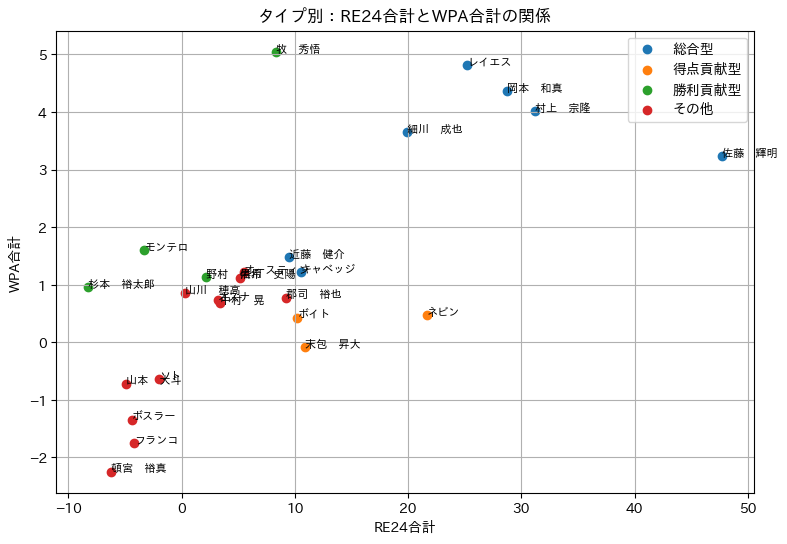

In [110]:
plt.figure(figsize=(9, 6))

for t in type_df["タイプ"].unique():
    data = type_df[type_df["タイプ"] == t]
    plt.scatter(data["RE24合計"], data["WPA合計"], label=t)

for _, row in type_df.iterrows():
    plt.text(row["RE24合計"], row["WPA合計"], row[batter_col], fontsize=8)

plt.xlabel("RE24合計")
plt.ylabel("WPA合計")
plt.title("タイプ別：RE24合計とWPA合計の関係")
plt.legend()
plt.grid(True)
plt.show()

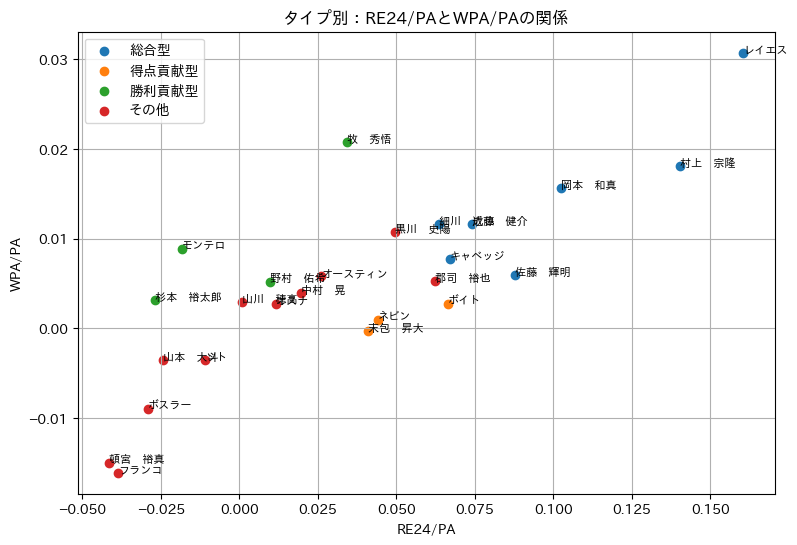

In [111]:
plt.figure(figsize=(9, 6))

for t in type_df["タイプ"].unique():
    data = type_df[type_df["タイプ"] == t]
    plt.scatter(data["RE24/PA"], data["WPA/PA"], label=t)

for _, row in type_df.iterrows():
    plt.text(row["RE24/PA"], row["WPA/PA"], row[batter_col], fontsize=8)

plt.xlabel("RE24/PA")
plt.ylabel("WPA/PA")
plt.title("タイプ別：RE24/PAとWPA/PAの関係")
plt.legend()
plt.grid(True)
plt.show()

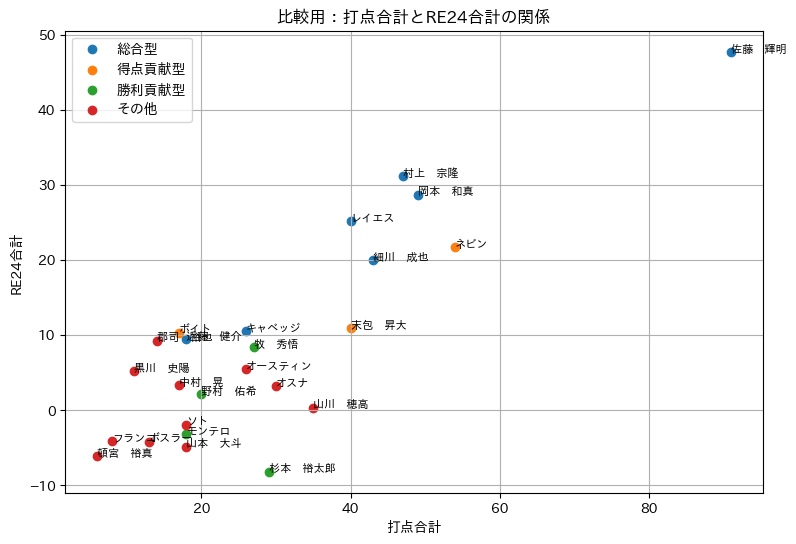

In [112]:
plt.figure(figsize=(9, 6))

for t in type_df["タイプ"].unique():
    data = type_df[type_df["タイプ"] == t]
    plt.scatter(data["打点合計"], data["RE24合計"], label=t)

for _, row in type_df.iterrows():
    plt.text(row["打点合計"], row["RE24合計"], row[batter_col], fontsize=8)

plt.xlabel("打点合計")
plt.ylabel("RE24合計")
plt.title("比較用：打点合計とRE24合計の関係")
plt.legend()
plt.grid(True)
plt.show()

In [113]:
type_df.to_csv("week3_type_classification_re24_wpa.csv", index=False, encoding="utf-8-sig")
type_summary.to_csv("week3_type_summary_re24_wpa.csv", index=False, encoding="utf-8-sig")

print("保存完了")
print("week3_type_classification_re24_wpa.csv")
print("week3_type_summary_re24_wpa.csv")

保存完了
week3_type_classification_re24_wpa.csv
week3_type_summary_re24_wpa.csv
